In [33]:
from pathlib import Path
import gzip
import json
from pprint import pprint
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import numpy as np
from stable_platform_matchings.domain.instance import Instance
import seaborn as sns

In [34]:
sns.set_theme(context="paper", style="ticks")

In [35]:
root = Path("../results/exp_3")
all_jsons = list(root.rglob("*.json.gz"))
graph_data_filename = "../data/graph_0-14960_00_new.pickle"
instance = Instance.from_yaml(Path('../data/anon_14_day_instances/2020-08-27.yaml'))

## Matchings

In [36]:
data = []
for file in all_jsons:
    with gzip.open(file, 'rt', encoding='utf-8') as f:
        aggregate_payload = json.load(f)

    for payload in aggregate_payload["runs"]:
        instance_id = payload["summary_pay"]["instance_snapshot"]["instance_id"]
        epsilons = payload["sampled_inputs"]["epsilons"]
        het_costs = payload["sampled_inputs"]["het_costs"]
        intermediaries = payload["summary_pay"]["instance_snapshot"]["intermediaries"]
        max_int_result = payload["summary_pay"]["platform_solve_result"]["max_intermediary_welfare_result"]
        max_farmer_result = payload["summary_pay"]["platform_solve_result"]["max_farmer_welfare_result"]

        for intermediary in intermediaries:
            intermediary_id = intermediary["id"]
            epsilon = epsilons[intermediary_id]
            het_cost = het_costs[intermediary_id]
            status_quo_quantity = intermediary["status_quo_quantity"]
            deviation_potential = epsilon + status_quo_quantity
            matched = float(intermediary_id in max_int_result["selected_intermediaries"])
            profit_max = max_int_result["intermediary_profits"][intermediary_id]/ instance.lc_to_usd
            profit_min = max_farmer_result["intermediary_profits"][intermediary_id] / instance.lc_to_usd

            data.append({
                "epsilon": epsilon,
                "het_cost": het_cost,
                "status_quo_quantity": status_quo_quantity,
                "deviation_potential": deviation_potential,
                "instance_id": instance_id,
                "intermediary_id": intermediary_id,
                "matched": matched,
                "profit_max": profit_max,
                "profit_min": profit_min
            })  

df = pd.DataFrame(data)

# filter out extreme deviation potentials
df = df[df["deviation_potential"] <= 12]
df["total_fixed_cost"] = (df["het_cost"] + instance.truck_fixed_cost) / instance.lc_to_usd


In [37]:
def currency_formatter(x, pos):
    return f'${x:.0f}'


plt.rcParams.update({
    "font.size": 10,
    "axes.labelsize": 10,
    "axes.titlesize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9
})

dev_pot_bins = np.linspace(2, 12, 7)
cost_bins = np.linspace(65, 110, 7)

df['dev_pot_bin'] = (
    np.digitize(df['deviation_potential'], dev_pot_bins) - 1
)
df['cost_bin'] = (
    np.digitize(df['total_fixed_cost'], cost_bins) - 1
)

In [38]:
df.describe()

,epsilon,het_cost,status_quo_quantity,deviation_potential,matched,profit_max,profit_min,total_fixed_cost,dev_pot_bin,cost_bin
count,54445.000000,5.444500e+04,54445.000000,54445.000000,54445.000000,54445.000000,54445.000000,54445.000000,54445.000000,54445.000000
mean,2.985976,5.980916e+05,1.899104,4.885081,0.311342,8.012689,5.137797,96.420112,1.256644,3.358802
std,1.725381,3.088233e+05,1.808665,2.477498,0.463046,18.224088,15.713070,21.298156,1.478428,2.322051
min,0.000097,-2.167264e+05,0.000000,0.000426,0.000000,0.000000,0.000000,40.225762,-1.000000,-1.000000
25%,1.499737,3.527804e+05,0.000000,3.068724,0.000000,0.000000,0.000000,79.502099,0.000000,1.000000
50%,2.981258,6.004630e+05,1.850000,4.810284,0.000000,0.000000,0.000000,96.583657,1.000000,4.000000
75%,4.480489,8.255957e+05,2.900000,6.611692,1.000000,2.278069,0.000000,112.110050,2.000000,6.000000
max,5.999749,1.700540e+06,10.300000,11.999968,1.000000,168.464110,168.401133,172.451027,5.000000,6.000000


### Figure: Heatmap of Intermediary Match Rate vs. Fixed Cost and Deviation Potential

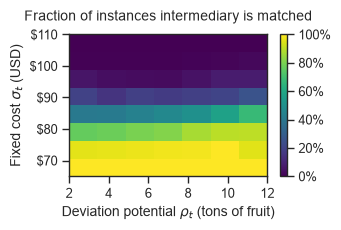

In [39]:
# compute probability that matched = 1 in each (deviation_potential, total_fixed_cost) bin
heatmap = (
    df
    .groupby(['dev_pot_bin', 'cost_bin'])
    ['matched']
    .mean()
    .unstack() 
    * 100
)

# plot heatmap
plt.figure(figsize=(3.5, 2.4))
plt.imshow(
    heatmap.T, origin='lower', aspect='auto',
    extent=(dev_pot_bins[0], dev_pot_bins[-1], cost_bins[0], cost_bins[-1]),
    cmap='viridis'
)
cbar = plt.colorbar()

# format colorbar ticks as percentages
cbar.ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:.0f}%'))

plt.xlabel(r'Deviation potential $\rho_t$ (tons of fruit)')
plt.gca().yaxis.set_major_formatter(FuncFormatter(currency_formatter))
plt.ylabel(r'Fixed cost $\sigma_t$ (USD)')
plt.title(r'Fraction of instances intermediary is matched', pad=10)
plt.tight_layout()
plt.savefig("../figures/exp_3/matched_heatplot.png", bbox_inches='tight', dpi=300) 
plt.show()

### Figure: Heatmap of Average Intermediary Profit vs. Fixed Cost and Deviation Potential

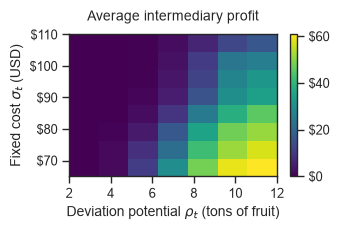

In [40]:
heatmap = df.groupby(['dev_pot_bin', 'cost_bin'])['profit_max'].mean().unstack()

# Plot heatmap
plt.figure(figsize=(3.5, 2.4))
plt.imshow(
    heatmap.T, origin='lower', aspect='auto',
    extent=(dev_pot_bins[0], dev_pot_bins[-1], cost_bins[0], cost_bins[-1]),
    cmap='viridis'
)

plt.gca().yaxis.set_major_formatter(FuncFormatter(currency_formatter))
plt.ylabel(r'Fixed cost $\sigma_t$ (USD)')
cbar = plt.colorbar(label='')
cbar.ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'${x:.0f}'))

plt.xlabel(r'Deviation potential $\rho_t$ (tons of fruit)')
plt.gca().yaxis.set_major_formatter(FuncFormatter(currency_formatter))
plt.title(r"Average intermediary profit", pad=10)
plt.tight_layout()

plt.savefig("../figures/exp_3/intermediary_profit.png", bbox_inches='tight', dpi=300) 
plt.show()

## Pricing and Payments

In [ ]:
data = []
for file in all_jsons:
    with gzip.open(file, 'rt', encoding='utf-8') as f:
        aggregate_payload = json.load(f)
    for payload in aggregate_payload["runs"]:
        instance_id = payload["summary_pay"]["instance_snapshot"]["instance_id"]
        epsilons = payload["sampled_inputs"]["epsilons"]
        het_costs = payload["sampled_inputs"]["het_costs"]
        quantities = payload["sampled_inputs"]["quantities"]

        farmers = payload["summary_pay"]["instance_snapshot"]["farmers"]
        intermediaries = payload["summary_pay"]["instance_snapshot"]["intermediaries"]
        max_int_result = payload["summary_pay"]["platform_solve_result"]["max_intermediary_welfare_result"]
        max_farmer_result = payload["summary_pay"]["platform_solve_result"]["max_farmer_welfare_result"]

        for farmer in farmers:
            farmer_id = farmer["id"]
            intermediary_id = farmer["intermediary_id"]

            quantity = quantities[farmer_id]
            payment_min = max_int_result["farmer_payments"][farmer_id]
            payment_max = max_farmer_result["farmer_payments"][farmer_id]

            intermediary = next(
                intermediary for intermediary in intermediaries 
                if intermediary["id"] == intermediary_id
            )

            intermediary_deviation_potential = (
                epsilons[intermediary_id] + intermediary["status_quo_quantity"]
            )
            intermediary_matched = max_int_result["intermediary_profits"][intermediary_id] > 10
            payment_per_kg = max_int_result["farmer_payments"][farmer_id] / quantities[farmer_id]

            

            data.append({
                "quantity": quantity,
                "instance_id": instance_id,
                "payment_min": payment_min,
                "payment_max": payment_max,
                "farmer_id": farmer_id,
                "dirt_to_mill": farmer["dirt_to_mill"] /(2625)/4,
                "paved_to_mill": farmer["paved_to_mill"] /(2625),
                "intermediary_deviation_potential": intermediary_deviation_potential,
                "intermediary_matched": intermediary_matched,
                "payment_per_kg": payment_per_kg / instance.lc_to_usd
            })  

df = pd.DataFrame(data)


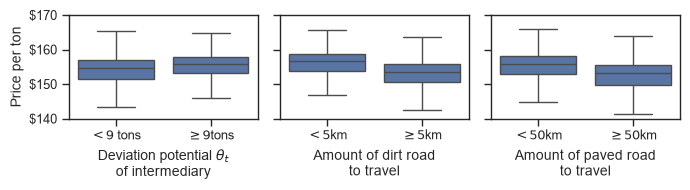

In [ ]:
plt.rcParams.update({
    "font.size": 10,
    "axes.labelsize": 10,
    "axes.titlesize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9
})

def dollar_formatter(x, pos):
    return f'${int(x)}'

formatter = FuncFormatter(dollar_formatter)

df['int_dev_pot_bin'] = pd.cut(
    df['intermediary_deviation_potential'],
    bins=[-float('inf'), 9, float('inf')],
    labels=[r'$< 9$ tons', r'$\geq 9$tons']
)

df['dirt_to_mill_bin'] = pd.cut(
    df['dirt_to_mill'],
    bins=[-float('inf'), 5, float('inf')],
    labels=[r'$< 5$km', r'$\geq 5$km']
)

df['paved_to_mill_bin'] = pd.cut(
    df['paved_to_mill'],
    bins=[-float('inf'), 50, float('inf')],
    labels=[r'$< 50$km', r'$\geq 50$km']
)

fig, axes = plt.subplots(1, 3, figsize=(7, 2), sharey=True)

# First plot: Power to Deviate
sns.boxplot(
    data=df,
    x='int_dev_pot_bin',
    y='payment_per_kg',
    showfliers=False,
    ax=axes[0]
)

axes[0].set_xlabel(r'Deviation potential $\theta_t$'+'\nof intermediary')
axes[0].set_ylabel('Price per ton')
axes[0].set_ylim(130, 170)
axes[0].yaxis.set_major_formatter(formatter)

# Second plot: Dirt road
sns.boxplot(
    data=df,
    x='dirt_to_mill_bin',
    y='payment_per_kg',
    showfliers=False,
    ax=axes[1]
)
axes[1].set_xlabel('Amount of dirt road\nto travel')
axes[1].set_ylabel('')
axes[1].set_ylim(130, 170)
axes[1].yaxis.set_major_formatter(formatter)

# Third plot: Paved road
sns.boxplot(
    data=df,
    x='paved_to_mill_bin',
    y='payment_per_kg',
    showfliers=False,
    ax=axes[2]
)
axes[2].set_xlabel('Amount of paved road\nto travel')
axes[2].set_ylabel('')
axes[2].set_ylim(140, 170)
axes[2].yaxis.set_major_formatter(formatter)

plt.tight_layout()
plt.savefig("../figures/exp_3/boxplots_prices.png", bbox_inches='tight', dpi=300)

plt.show()


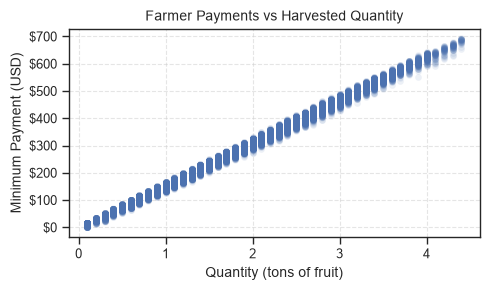

In [ ]:
plt.rcParams.update({
    "font.size": 10,
    "axes.labelsize": 10,
    "axes.titlesize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9
})

plt.figure(figsize=(5, 3))

sns.scatterplot(
    data=df,
    x='quantity',
    y=df['payment_min'] / instance.lc_to_usd,
    alpha=0.1,
    edgecolor='k',
    linewidth=0,
)

plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.xlabel('Quantity (tons of fruit)')
plt.ylabel('Minimum Payment (USD)')
plt.title('Farmer Payments vs Harvested Quantity')

plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig("../figures/exp_3/farmer_payments.png", bbox_inches='tight', dpi=300) 

plt.show()